#📌 Extracción

In [10]:
import pandas as pd

datos = pd.read_json('/content/TelecomX_Data.json')

In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [13]:
datos.sample(5)

,customerID,Churn,customer,phone,internet,account
4309,5919-TMRGD,Yes,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5902,8064-RAVOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
1922,2719-BDAQO,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7133,9819-FBNSV,No,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4825,6614-FHDBO,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [14]:
customer_df = pd.json_normalize(datos['customer'])
phone_df = pd.json_normalize(datos['phone'])
internet_df = pd.json_normalize(datos['internet'])
account_df = pd.json_normalize(datos['account'])

# Unir todo al dataframe original
df = pd.concat(
    [datos.drop(columns=['customer','phone','internet','account']),
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [18]:
# Numéricas
df['Charges.Monthly'] = pd.to_numeric(df['Charges.Monthly'], errors='coerce')
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# SeniorCitizen si viene como 0/1 en string
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

In [19]:
df.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [20]:
df = df.dropna()

In [21]:
churn_rate = df['Churn'].mean()
print(f"Tasa de churn: {churn_rate:.2%}")

Tasa de churn: 26.58%


#📊 Carga y análisis

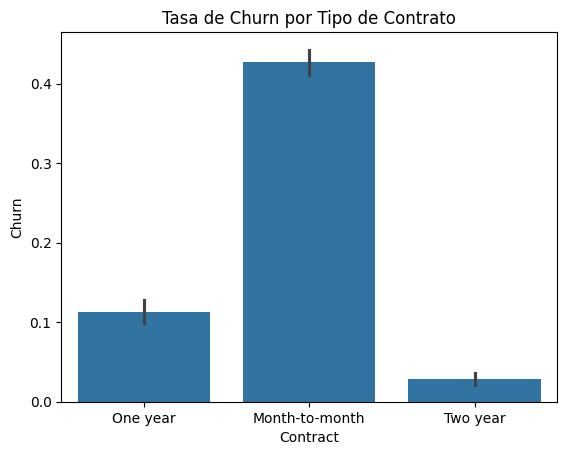

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Tasa de Churn por Tipo de Contrato")
plt.show()

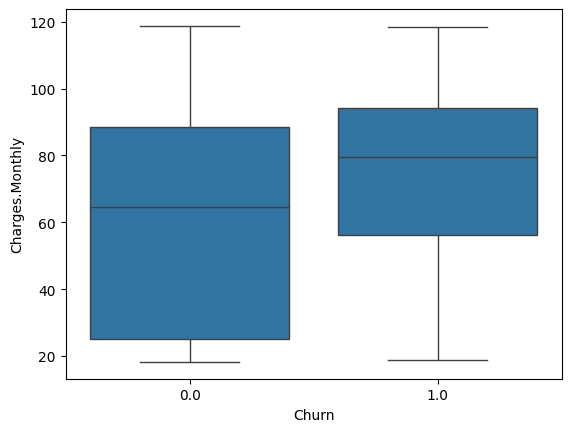

In [24]:
sns.boxplot(x='Churn', y='Charges.Monthly', data=df)
plt.show()

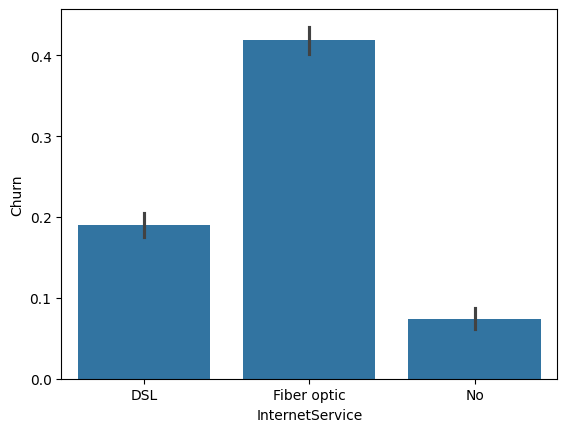

In [25]:
sns.barplot(x='InternetService', y='Churn', data=df)
plt.show()

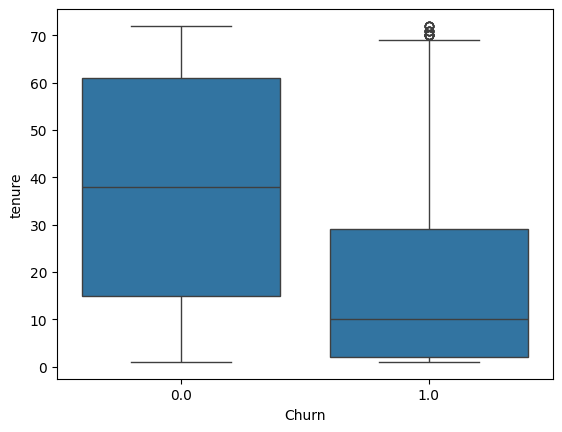

In [26]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

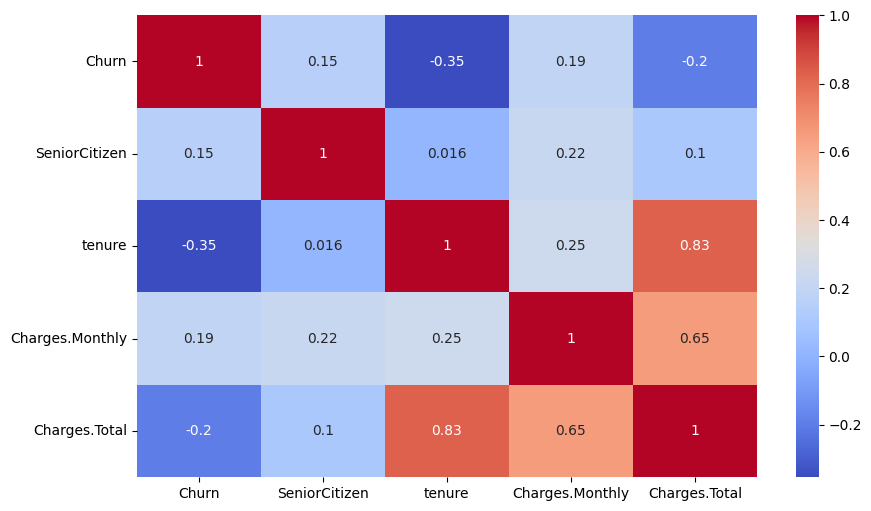

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#📄Informe final

#Informe Final TelecomX Churn

##Introducción
Telecom X enfrenta una tasa elevada de cancelación de clientes que impacta directamente en sus ingresos recurrentes y en la estabilidad del negocio. El objetivo de este análisis fue recopilar, transformar y explorar los datos disponibles para identificar los factores asociados a la evasión, generar insights accionables y sentar las bases para futuros modelos predictivos.

El proyecto se estructuró bajo un enfoque de ETL (Extracción, Transformación y Carga) seguido de un Análisis Exploratorio de Datos (EDA) orientado a la toma de decisiones estratégicas.

##Proceso de Preparación de Datos (ETL)
Los datos fueron obtenidos en formato JSON desde una fuente estructurada, con varias columnas que contenían información anidada correspondiente a características del cliente, servicios contratados y detalles de cuenta. Fue necesario normalizar estas estructuras para convertirlas en un dataset tabular adecuado para el análisis.

Durante la fase de transformación se expandieron las columnas anidadas, se estandarizaron los nombres de variables y se convirtieron los tipos de datos. Variables como MonthlyCharges y TotalCharges fueron transformadas a formato numérico, mientras que la variable objetivo Churn fue codificada en formato binario para facilitar su análisis. También se gestionaron valores nulos y se validó la consistencia de los registros.

El resultado fue un dataset limpio y estructurado, apto para análisis exploratorio y modelado predictivo.

##Análisis Exploratorio de Datos
El análisis se centró en identificar patrones asociados a la cancelación del servicio y en comprender el perfil de los clientes con mayor probabilidad de evasión.

La tasa general de churn indica que una proporción significativa de clientes cancela el servicio, lo que confirma la necesidad de intervenciones estratégicas. La evasión no se distribuye de manera homogénea, sino que se concentra en determinados segmentos.

Uno de los factores más relevantes es el tipo de contrato. Los clientes con contratos mensuales presentan una tasa de cancelación considerablemente más alta que aquellos con contratos de uno o dos años. Esto sugiere que la estabilidad contractual reduce el riesgo de abandono, mientras que la flexibilidad mensual facilita la decisión de salida.

La antigüedad del cliente también muestra un patrón claro. Los clientes con menor tiempo de permanencia presentan mayor probabilidad de cancelar, especialmente durante los primeros meses del servicio. A medida que aumenta la antigüedad, la tasa de churn disminuye de forma significativa. Esto indica que el riesgo es mayor en las etapas tempranas del ciclo de vida del cliente.

En cuanto a los cargos mensuales, se observa que los clientes con facturación más elevada tienden a presentar mayores tasas de cancelación. Esto puede estar asociado a una percepción de bajo valor relativo frente al precio pagado o a una mayor sensibilidad al costo en ciertos segmentos.

El tipo de servicio de internet también resulta relevante. Los clientes con fibra óptica presentan mayores niveles de churn en comparación con quienes utilizan DSL. Este comportamiento puede estar relacionado con expectativas de desempeño, problemas de calidad o estructura de precios.

Asimismo, los clientes que no cuentan con servicios adicionales como seguridad en línea o soporte técnico presentan mayor probabilidad de evasión. Esto sugiere que una mayor integración de servicios aumenta la dependencia del cliente y reduce su propensión a cancelar.

Perfil del Cliente con Mayor Riesgo
A partir de los patrones identificados, el perfil con mayor probabilidad de churn corresponde a clientes con contrato mensual, baja antigüedad, cargos mensuales elevados y servicio de fibra óptica, especialmente cuando no cuentan con servicios adicionales de soporte o seguridad.

Este perfil permite segmentar de manera clara a los clientes con mayor riesgo y orientar estrategias de retención específicas.

##Implicaciones para el Negocio
El churn representa una amenaza directa a la rentabilidad, ya que incrementar la retención suele ser más eficiente que adquirir nuevos clientes. La evidencia muestra que la evasión no es aleatoria, sino que responde a características contractuales, económicas y de ciclo de vida.

Reducir la tasa de cancelación en los segmentos identificados podría generar un impacto significativo en ingresos recurrentes y estabilidad financiera.

##Recomendaciones Estratégicas
Se recomienda implementar incentivos que promuevan la migración de contratos mensuales a contratos de mayor duración, mediante descuentos o beneficios adicionales. También es fundamental fortalecer las estrategias de acompañamiento durante los primeros meses del cliente, ya que es el periodo de mayor vulnerabilidad.

Es conveniente revisar la estructura de precios y propuesta de valor de los planes con cargos más elevados, especialmente en el segmento de fibra óptica. Asimismo, fomentar la adopción de servicios adicionales puede contribuir a aumentar la retención al incrementar el nivel de integración del cliente con la compañía.

Finalmente, el siguiente paso lógico es desarrollar un modelo predictivo que permita asignar un puntaje de riesgo a cada cliente y activar acciones preventivas antes de que se produzca la cancelación.

##Conclusión
El análisis confirma que la evasión de clientes en Telecom X está asociada a variables contractuales, financieras y de comportamiento. El tipo de contrato, la antigüedad, el nivel de cargos mensuales y el tipo de servicio son factores determinantes en la probabilidad de cancelación.

La empresa cuenta con información suficiente para implementar estrategias de retención basadas en datos. Con una correcta segmentación y un enfoque proactivo, es posible reducir de manera significativa la tasa de churn y mejorar la rentabilidad del negocio.